In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [1]:
watt_arr = [0, 10, 20, 40, 60, 80]
df_sum = pd.DataFrame()
for i in range(1, 6):
    df = pd.read_excel("./labo1/linear_approximation.xlsx", header=6, index_col=0, sheet_name="Sheet" + str(i))
    df["W"] = watt_arr[i]
    df_sum = pd.concat([df_sum, df])

NameError: name 'pd' is not defined

In [12]:
df_sum

,Number,W
Time[s],,
0,98433.561371,10
10,94203.487920,10
20,91517.336375,10
30,86539.457397,10
40,81777.430583,10
50,76858.586685,10
60,73447.031317,10
0,99029.902000,20
10,91712.170320,20


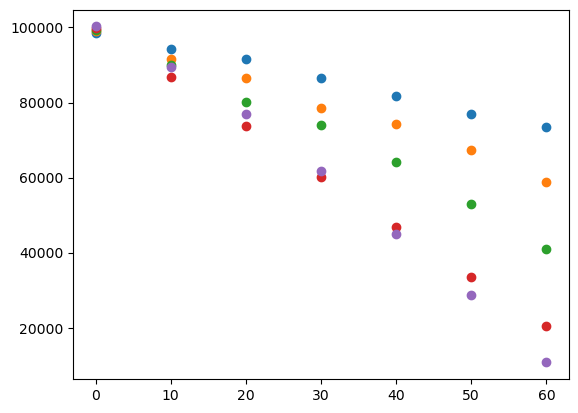

In [15]:
groups = df_sum.groupby("W")
for name, group in groups:
    plt.scatter(group.index, group["Number"], label="W")

In [2]:
# 殺菌力を傾きで表現。傾きがマイナスなので、プラスに変換。
p_list = []
p_list.append(0)
for name, group in groups:
    # 殺菌力は傾きである
    params = np.polyfit(group.index, group["Number"], 1)
    p_list.append(-float(params[0]))

NameError: name 'groups' is not defined

In [22]:
p_list

[0,
 426.3903515160271,
 649.889982642858,
 947.7399997936398,
 1327.8571428571436,
 1508.104196494785]

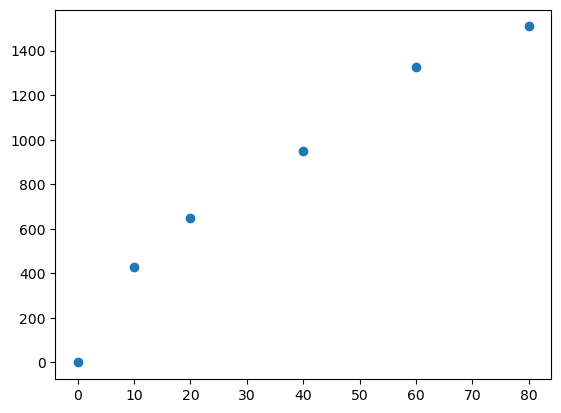

In [23]:
plt.scatter(watt_arr, p_list)

In [24]:
def curve(x, a, b):
    return a * x ** b

In [28]:
ret, _ = curve_fit(curve, watt_arr, p_list, p0=[0, 0])

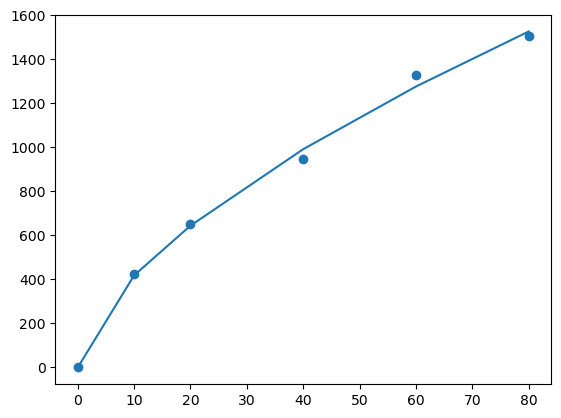

In [29]:
plt.scatter(watt_arr, p_list)
plt.plot(watt_arr, curve(watt_arr, ret[0], ret[1]))